In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv("csv dataset.csv")

In [17]:
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [19]:
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [21]:
df.tail()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021
1114,1114,Wyoming,38000,58,242000,242000,2.07,4562000,2021


In [25]:
df.shape

(1115, 9)

In [27]:
#to check datatype and number of non null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [43]:
# to check for null values
df.isnull().sum()

Unnamed: 0             0
state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64

In [41]:
# to checkfor duplicate values
df.duplicated().sum()

0

In [53]:
# drop the unnamed colomns as it is unused
df.drop("Unnamed: 0",axis=1,inplace=True)

In [55]:
df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


EDA

In [68]:
df.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='object')

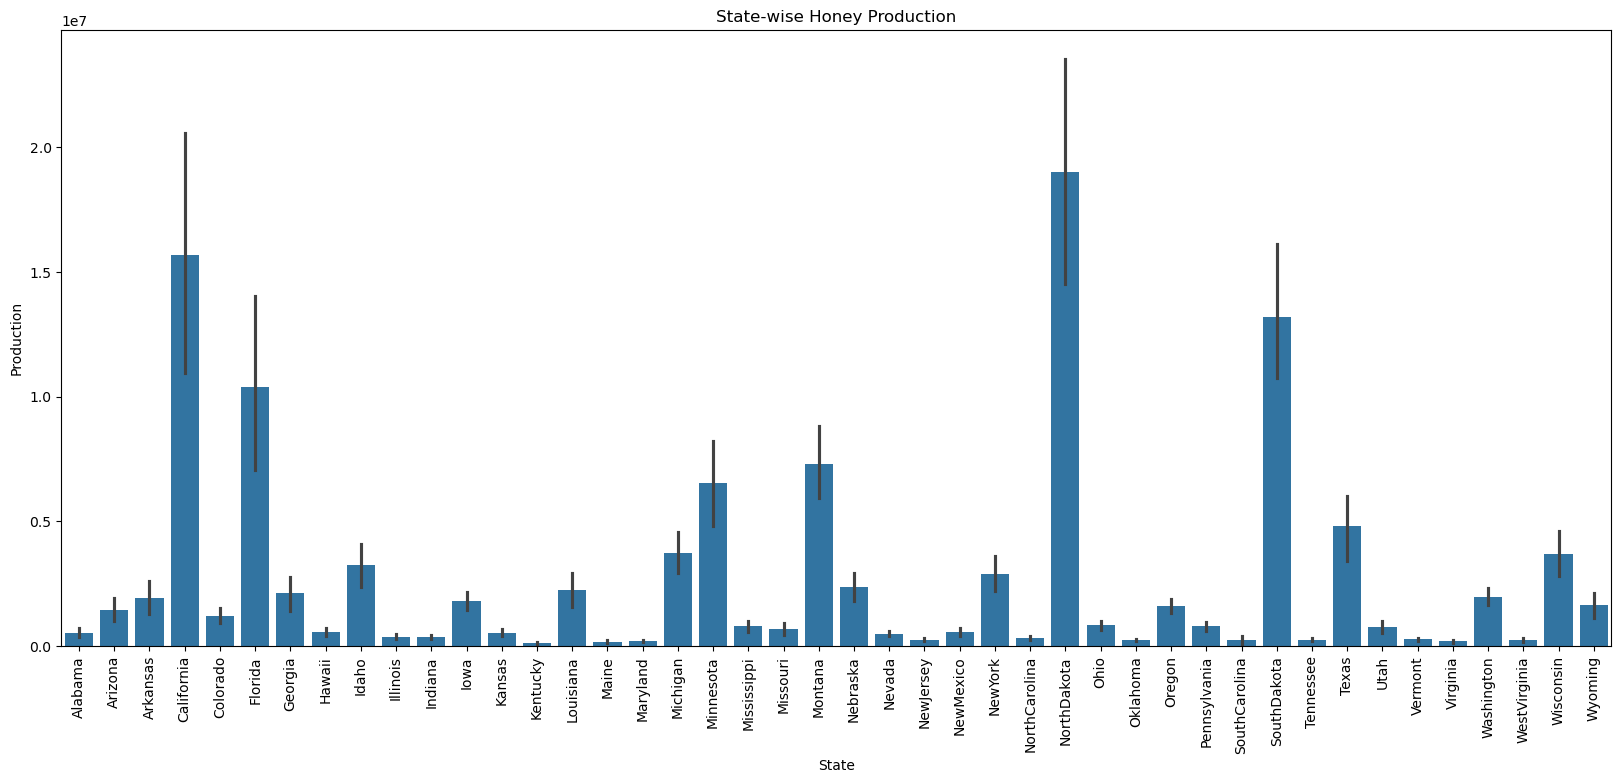

In [78]:
# State-wise production
plt.figure(figsize=(20, 8))
# OR sns.barplot(x='state', y='production', data=df)
sns.barplot(x=df['state'], y=df['production'])
plt.title('State-wise Honey Production')
plt.xlabel('State')
plt.ylabel('Production')
plt.xticks(rotation=90)
plt.show()

In [82]:
#state-wise production
sp=df.groupby("state")["production"].sum().reset_index()

In [84]:
sp

,state,production
0,Alabama,14467000
1,Arizona,38844000
2,Arkansas,51846000
3,California,423876000
4,Colorado,32660000
5,Florida,280934000
6,Georgia,57426000
7,Hawaii,15420000
8,Idaho,87188000
9,Illinois,9864000


In [100]:
top5=sp.sort_values(by='production',ascending=False).head()
top5

,state,production
28,NorthDakota,513742000
3,California,423876000
34,SouthDakota,355726000
5,Florida,280934000
21,Montana,197173000


<Axes: xlabel='state', ylabel='production'>

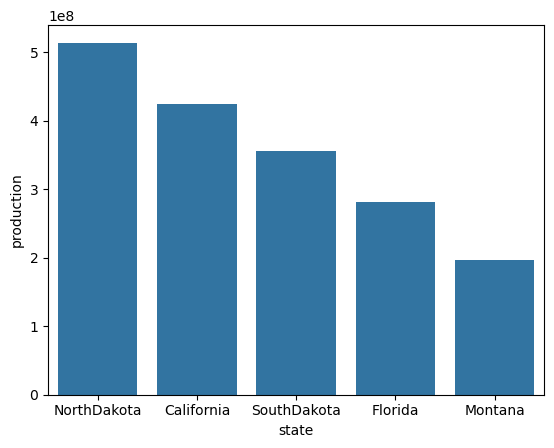

In [108]:
sns.barplot(x=top5['state'], y=top5['production'])

<Axes: xlabel='state', ylabel='production'>

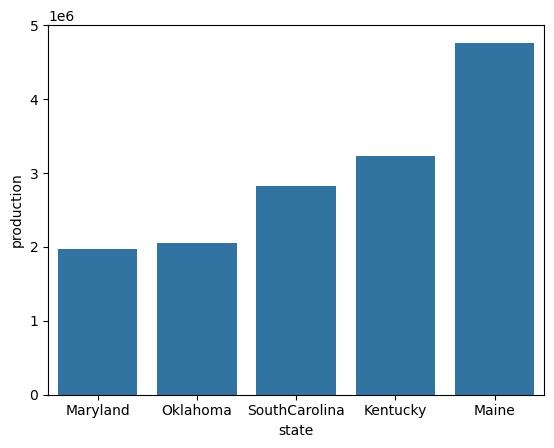

In [116]:
bot5=sp.sort_values(by='production',ascending=True).reset_index().head()
sns.barplot(x=bot5['state'], y=bot5['production'])

In [120]:
s_price=df.groupby("state")["average_price"].sum().reset_index()
s_price

,state,average_price
0,Alabama,4057.61
1,Arizona,2978.77
2,Arkansas,2870.45
3,California,2954.06
4,Colorado,3200.56
5,Florida,2967.52
6,Georgia,3260.68
7,Hawaii,3719.13
8,Idaho,2869.71
9,Illinois,5842.43


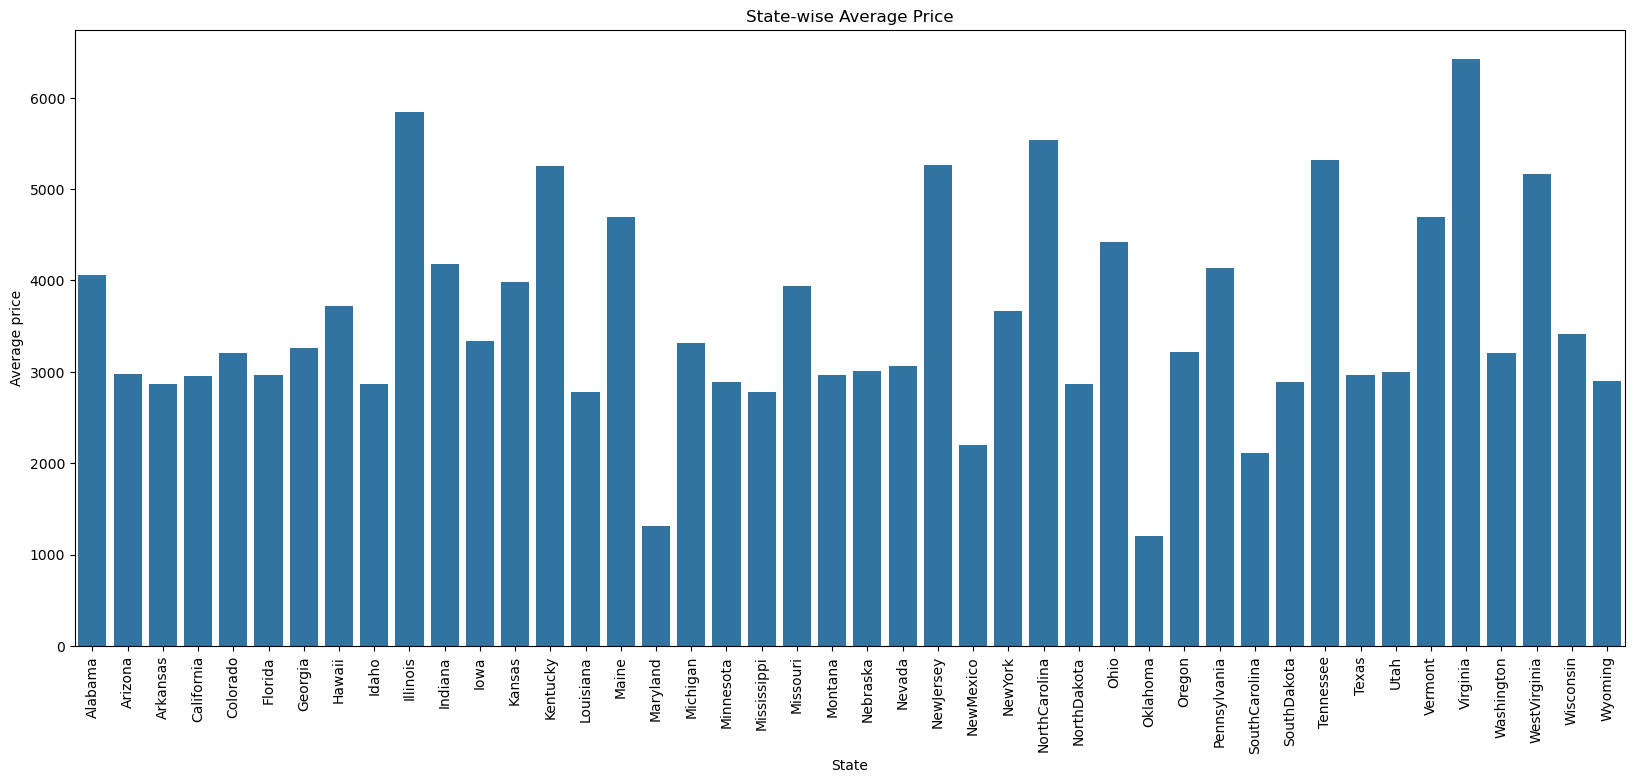

In [122]:
plt.figure(figsize=(20, 8))
# OR sns.barplot(x='state', y='production', data=df)
sns.barplot(x=s_price['state'], y=s_price['average_price'])
plt.title('State-wise Average Price')
plt.xlabel('State')
plt.ylabel('Average price')
plt.xticks(rotation=90)
plt.show()

In [136]:
tp5=s_price.sort_values(by='average_price',ascending=False).reset_index().head()
tp5

,index,state,average_price
0,39,Virginia,6419.69
1,9,Illinois,5842.43
2,27,NorthCarolina,5540.21
3,35,Tennessee,5318.06
4,24,NewJersey,5262.74


<Axes: xlabel='state', ylabel='average_price'>

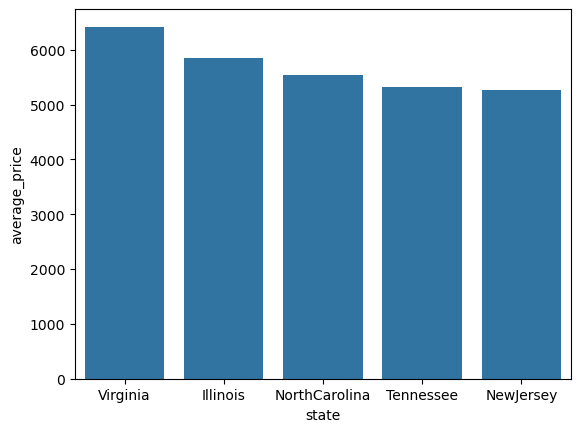

In [140]:
sns.barplot(x=tp5['state'], y=tp5['average_price'])

<Axes: xlabel='state', ylabel='average_price'>

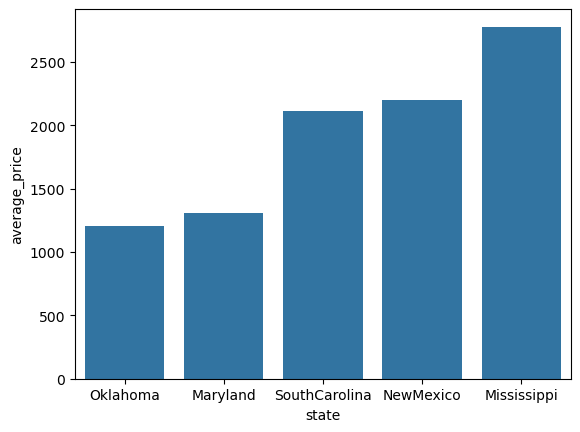

In [146]:
bt5=s_price.sort_values(by='average_price',ascending=True).reset_index().head()
sns.barplot(x=bt5['state'], y=bt5['average_price'])

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("csv dataset.csv")

In [11]:
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [13]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [15]:
df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("csv dataset.csv")
df.drop("Unnamed: 0",axis=1,inplace=True)
Year_Avg_Price = df.groupby('year')['average_price'].sum().reset_index()
Year_Avg_Price

,year,average_price
0,1995,3293.00
1,1996,4381.00
2,1997,3927.00
3,1998,3600.00
4,1999,3454.00
5,2000,3398.00
6,2001,3804.00
7,2002,5861.00
8,2003,6647.00
9,2004,5294.00


In [17]:
df.year.unique()

array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021], dtype=int64)

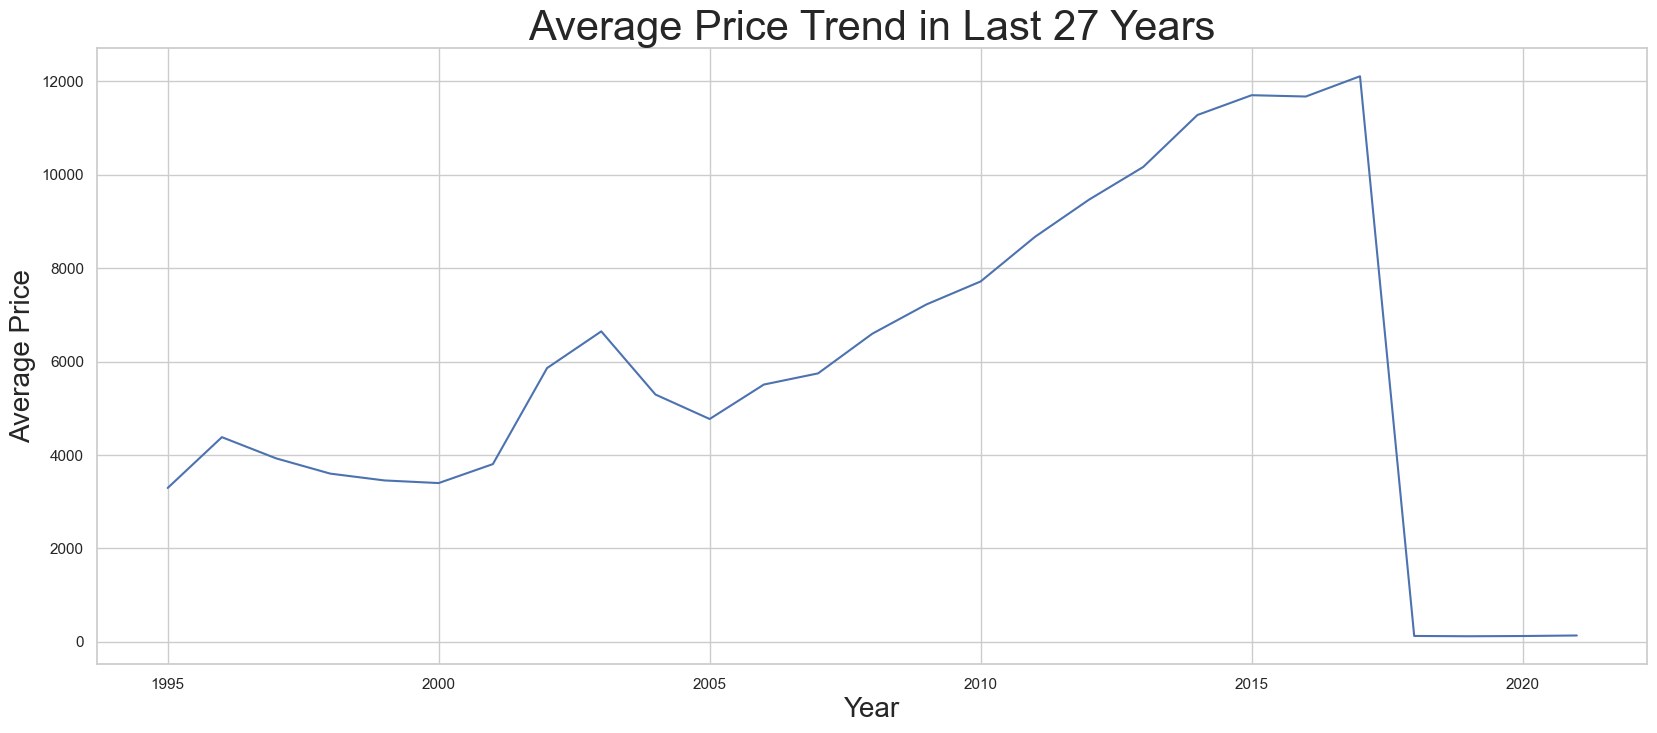

In [19]:
plt.figure(figsize=(20, 8))
sns.set(style='whitegrid')
sns.lineplot(x='year', y='average_price', data=Year_Avg_Price)
plt.title('Average Price Trend in Last 27 Years', fontsize=30)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Average Price', fontsize=20)
plt.show()

Which states are rarely contributing over 27 years

In [22]:
df_rarely_cont = df.groupby(['state', 'year'])['production'].sum().reset_index()
df_rarely_cont

,state,year,production
0,Alabama,1995,928000
1,Alabama,1996,1024000
2,Alabama,1997,924000
3,Alabama,1998,1136000
4,Alabama,1999,1156000
...,...,...,...
1110,Wyoming,2017,186000
1111,Wyoming,2018,175000
1112,Wyoming,2019,306000
1113,Wyoming,2020,608000


In [24]:
Bottom_df_rarely_cont = df_rarely_cont.sort_values(by='production', ascending=True).reset_index().head(5)
Bottom_df_rarely_cont.drop('index', axis=1, inplace=True)
Bottom_df_rarely_cont

,state,year,production
0,Kentucky,2011,12000
1,Alabama,2015,13000
2,Alabama,2018,14000
3,SouthCarolina,2018,15000
4,Maine,2011,17000


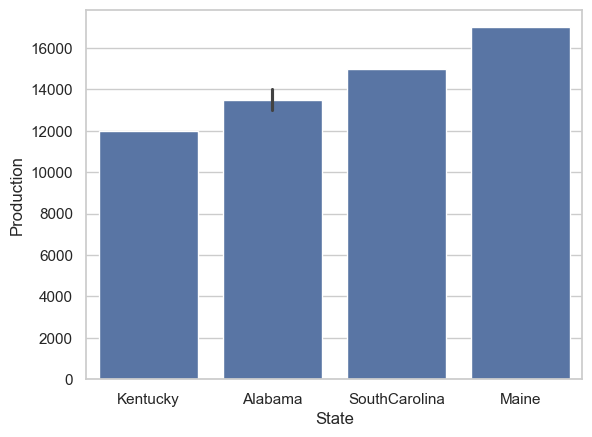

In [32]:
sns.barplot(x=Bottom_df_rarely_cont['state'], y=Bottom_df_rarely_cont['production'])
plt.xlabel('State')
plt.ylabel('Production')
plt.show()

In [34]:
mean_change_avg_df = df.groupby('year')['average_price'].mean()
mean_change_avg_df

year
1995     74.840909
1996     99.568182
1997     91.325581
1998     83.720930
1999     80.325581
2000     79.023256
2001     88.465116
2002    133.204545
2003    151.068182
2004    132.350000
2005    116.341463
2006    134.341463
2007    140.170732
2008    160.878049
2009    176.195122
2010    192.900000
2011    216.725000
2012    236.700000
2013    260.717949
2014    282.025000
2015    292.625000
2016    291.925000
2017    302.775000
2018      3.083500
2019      2.925500
2020      3.050000
2021      3.334250
Name: average_price, dtype: float64

In [36]:
change_mean = mean_change_avg_df.loc[1995] - mean_change_avg_df.loc[2021]
change_mean

71.5066590909091

In [38]:
prob = df.groupby('year')['production'].sum().reset_index()
prob

,year,production
0,1995,210272000
1,1996,197995000
2,1997,191176000
3,1998,219321000
4,1999,204585000
5,2000,220320000
6,2001,185403000
7,2002,170732000
8,2003,180741000
9,2004,182379000


In [46]:
Highest_prod = df.groupby('year')['production'].sum().reset_index()
Highest_prod
Highest_prod.sort_values(by='production', ascending=False).head(1)

,year,production
5,2000,220320000


In [62]:
Highest_Production_State = df.groupby(['state','year'])['production'].sum().reset_index()
Highest_Production_State

,state,year,production
0,Alabama,1995,928000
1,Alabama,1996,1024000
2,Alabama,1997,924000
3,Alabama,1998,1136000
4,Alabama,1999,1156000
...,...,...,...
1110,Wyoming,2017,186000
1111,Wyoming,2018,175000
1112,Wyoming,2019,306000
1113,Wyoming,2020,608000


In [64]:
State_2000_year = Highest_Production_State.loc[(Highest_Production_State['year']==2000)]
State_2000_year

,state,year,production
5,Alabama,2000,1248000
32,Arizona,2000,2360000
59,Arkansas,2000,5115000
86,California,2000,30800000
113,Colorado,2000,1740000
140,Florida,2000,24360000
167,Georgia,2000,3135000
194,Hawaii,2000,784000
221,Idaho,2000,4700000
248,Illinois,2000,488000


In [66]:
State_2000_year.sort_values(by='production', ascending=False).head(1)

,state,year,production
721,NorthDakota,2000,33350000


In [68]:
df.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='object')

In [70]:
Highest_Colony = df.groupby(['state','year'])['colonies_number'].sum().reset_index()
Highest_Colony

,state,year,colonies_number
0,Alabama,1995,16000
1,Alabama,1996,16000
2,Alabama,1997,14000
3,Alabama,1998,16000
4,Alabama,1999,17000
...,...,...,...
1110,Wyoming,2017,39000
1111,Wyoming,2018,39000
1112,Wyoming,2019,39000
1113,Wyoming,2020,38000


In [72]:
State_2000_Colony = Highest_Colony.loc[(Highest_Colony['year']==2000)]
State_2000_Colony

,state,year,colonies_number
5,Alabama,2000,16000
32,Arizona,2000,40000
59,Arkansas,2000,55000
86,California,2000,440000
113,Colorado,2000,29000
140,Florida,2000,232000
167,Georgia,2000,55000
194,Hawaii,2000,7000
221,Idaho,2000,100000
248,Illinois,2000,8000


In [76]:
bar = State_2000_Colony.sort_values(by='colonies_number', ascending=False).head(1)
bar

,state,year,colonies_number
86,California,2000,440000
